# House Price Prediction — Model Notebook

End-to-end notebook: load & inspect the **House Price** dataset (Kaggle, ~187k Indian
property listings), explore it, clean it, engineer features, train and compare
regression models, and export the winning model as `house_price.pkl` for the
FastAPI backend.


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)  # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**How many rows?** 187,531 raw listings, 21 columns.

**Numeric vs text columns.** Only `Price (in rupees)`, `Dimensions`, and `Plot Area` are
loaded as numeric dtypes; everything else — including `Amount(in rupees)`, `Carpet Area`,
`Super Area`, `Floor`, `Bathroom`, `Balcony`, `Car Parking` — is stored as free-text and
needs parsing before it can be used in a model.

**Most missing values.** `Plot Area` and `Dimensions` are missing for essentially every
row (~100%) and are dropped. `Society` (~58%), `Super Area` (~57%), `Car Parking` (~55%),
`overlooking` (~43%), `Carpet Area` (~43%), and `facing` (~37%) all have substantial
missingness that has to be handled during cleaning.


## 2.2 Exploratory Data Analysis (EDA)

Before cleaning, look at the raw target and a few key relationships. We first build a
numeric `price_clean` column (see §2.3 for the full parser) just so we can plot it here.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def parse_amount(x):
    """'42 Lac' -> 4_200_000.0 ; '1.2 Cr' -> 12_000_000.0 ; 'Call for Price' -> None"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df_eda = df.dropna(subset=["price_clean"]).copy()
df_eda.shape

(177847, 22)

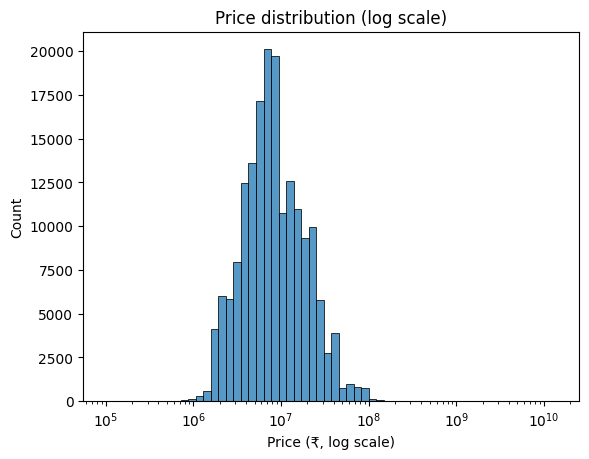

In [7]:
sns.histplot(df_eda["price_clean"], log_scale=True, bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (₹, log scale)")
plt.show()

The raw price is extremely right-skewed — a handful of very expensive listings
stretch the axis, which is why we train on `log1p(price)` later (§2.4) rather than
the raw rupee value.


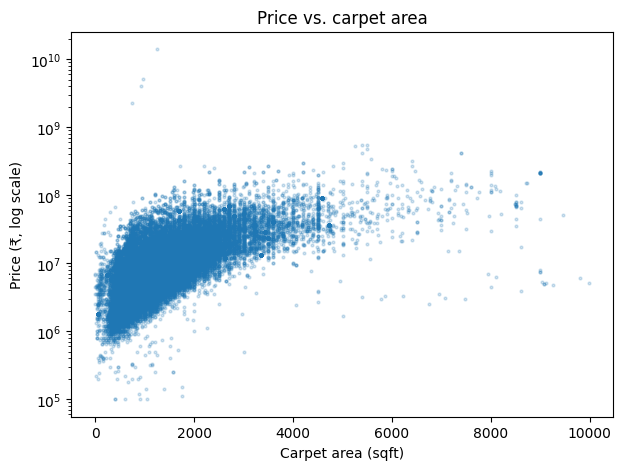

In [8]:
def parse_area(x):
    """'1200 sqft' -> 1200.0 ; '140 sqm' -> ~1507.0 sqft"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip().replace(",", ""))
        if "sqm" in x:
            return float(x.replace("sqm", "").strip().replace(",", "")) * 10.764
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip().replace(",", "")) * 9.0
        return float(x.replace(",", ""))
    except ValueError:
        return None

df_eda["carpet_area_sqft"] = df_eda["Carpet Area"].apply(parse_area)
super_area_sqft = df_eda["Super Area"].apply(parse_area)
df_eda["carpet_area_sqft"] = df_eda["carpet_area_sqft"].fillna(super_area_sqft)

plot_df = df_eda.dropna(subset=["carpet_area_sqft"])
plot_df = plot_df[(plot_df["carpet_area_sqft"] > 0) & (plot_df["carpet_area_sqft"] < 10000)]

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["carpet_area_sqft"], plot_df["price_clean"], s=4, alpha=0.2)
plt.yscale("log")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (₹, log scale)")
plt.title("Price vs. carpet area")
plt.show()

Price rises with area as expected, but the relationship is noisy — location,
furnishing, and building quality all shift the price-per-sqft, which is exactly why a
single-feature model would underperform a model that also uses location and amenities.


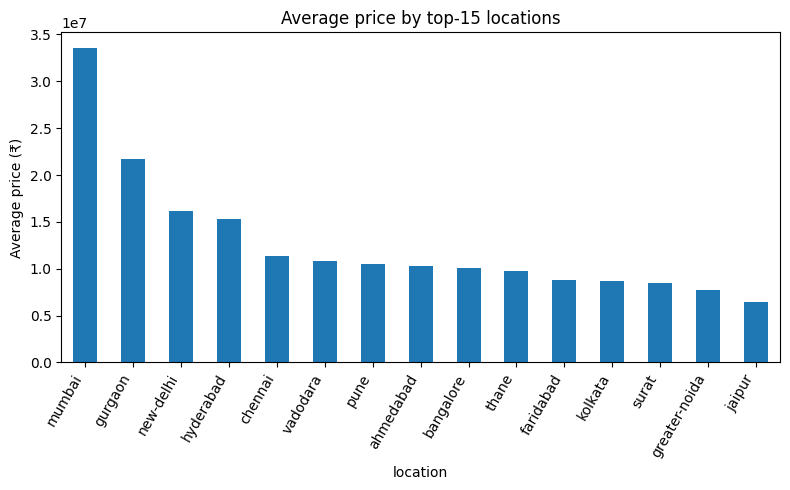

In [9]:
top15 = df_eda["location"].value_counts().nlargest(15).index
avg_price_by_location = (
    df_eda[df_eda["location"].isin(top15)]
    .groupby("location")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_price_by_location.plot(kind="bar")
plt.ylabel("Average price (₹)")
plt.title("Average price by top-15 locations")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

`new-delhi`, `bangalore`, `kolkata`, and `gurgaon` have both the highest listing
counts and, along with `gurgaon`, some of the highest average prices — confirming
`location` is an important predictive feature and justifying the top-N grouping used in
cleaning (long-tail locations get too few samples to model individually).


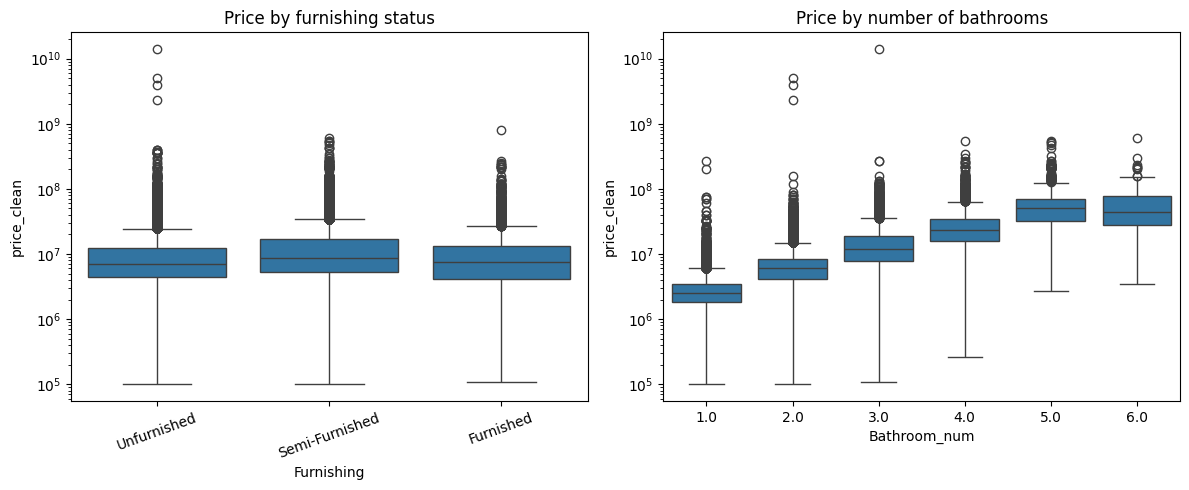

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_eda, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis="x", rotation=20)

bath_df = df_eda.copy()
bath_df["Bathroom_num"] = pd.to_numeric(bath_df["Bathroom"], errors="coerce")
bath_df = bath_df[bath_df["Bathroom_num"].between(1, 6)]
sns.boxplot(data=bath_df, x="Bathroom_num", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

Furnished properties command a visible premium over unfurnished ones, and price
climbs steadily with bathroom count — both are useful signals for the model.


## 2.3 Cleaning & Feature Engineering

This dataset is messy on purpose. We handle each problem listed in the project guide:
1. Parse `Amount(in rupees)` text into a numeric `price_clean` (done above).
2. Parse `Carpet Area` / `Super Area` text into `carpet_area_sqft`, normalised to sqft.
3. Parse `Floor` (`"3 out of 10"`, `"Ground"`, `"Basement"`) into `floor_num`.
4. Convert `Bathroom` / `Balcony` / `Car Parking` to numeric, impute missing values.
5. Group the long tail of `location` values (thousands of distinct values) into the
   top-50 plus `"other"`.
6. Drop columns that are mostly empty or not useful as model features
   (`Index`, `Title`, `Description`, `Dimensions`, `Plot Area`, `Society`, `Car Parking`,
   `overlooking`, `Status`, `Price (in rupees)`).
7. Remove outliers by price-per-sqft (below the 1st / above the 99th percentile).


In [11]:
df = df.copy()
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After price parsing:", df.shape)

After price parsing: (177847, 22)


In [12]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
super_area_sqft = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area_sqft)
df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]
print("After area parsing:", df.shape)

After area parsing: (177732, 23)


In [13]:
def parse_floor(x):
    """'3 out of 10' -> 3 ; 'Ground out of 5' -> 0 ; 'Basement' -> -1"""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    part = x.split("out of")[0].strip()
    if "ground" in part:
        return 0
    if "basement" in part:
        return -1
    if "lower" in part:
        return 0
    if "upper" in part:
        return 1
    try:
        return float(part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [14]:
def parse_num(x):
    if pd.isna(x):
        return None
    try:
        return float(x)
    except (ValueError, TypeError):
        return None

df["bathroom"] = df["Bathroom"].apply(parse_num)
df["balcony"] = df["Balcony"].apply(parse_num)

# Impute: median for bathroom (almost always present & meaningful),
# 0 for balcony (missing usually means "not mentioned" i.e. none).
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)

In [15]:
TOP_N = 50
top_locations = df["location"].value_counts().nlargest(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
print(df["location_grouped"].nunique(), "distinct location buckets (incl. 'other')")

for c in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[c] = df[c].fillna("Unknown")

51 distinct location buckets (incl. 'other')


In [16]:
useless_cols = ["Index", "Title", "Description", "Dimensions", "Plot Area",
                "Society", "Car Parking", "overlooking", "Status", "Price (in rupees)"]
df = df.drop(columns=[c for c in useless_cols if c in df.columns])
df.columns.tolist()

['Amount(in rupees)',
 'location',
 'Carpet Area',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'Bathroom',
 'Balcony',
 'Ownership',
 'Super Area',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'location_grouped']

In [17]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
print(f"Removed {before - len(df)} price-per-sqft outliers -> {df.shape}")

Removed 3468 price-per-sqft outliers -> (174264, 18)


**Performance note.** This container has a single CPU core. Fitting a 100-tree
Random Forest on the full ~174k cleaned rows takes well over 20 minutes here, which
isn't a good notebook experience. We train on a random 60,000-row subsample
(`random_state=42`) — still a large, representative sample — and keep the full cleaned
dataset available for anyone who wants to retrain on more data / more cores.


In [18]:
SAMPLE_SIZE = 60_000
df_model = df.sample(n=SAMPLE_SIZE, random_state=42) if len(df) > SAMPLE_SIZE else df
df_model.shape

(60000, 18)

## 2.4 Build a Pipeline & Train

We bundle preprocessing (imputation, scaling, one-hot encoding) inside a scikit-learn
`Pipeline` + `ColumnTransformer`, and wrap that in a `TransformedTargetRegressor` so the
model is trained on `log1p(price)` (price is heavily skewed — see §2.2) and
automatically inverted with `expm1` at prediction time. This keeps the *exported* model
a single object that takes raw feature values in and returns a real rupee price out —
no manual log/exp handling needed in the backend.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from target_transform import log1p_transform, expm1_inverse_transform

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df_model[numeric_features + categorical_features]
y = df_model["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

def make_model(regressor):
    inner = Pipeline([("prep", preprocessor), ("reg", regressor)])
    return TransformedTargetRegressor(
        regressor=inner, func=log1p_transform, inverse_func=expm1_inverse_transform
    )

> **Note on `log1p_transform` / `expm1_inverse_transform`.** These live in the small
> `target_transform.py` module next to this notebook (rather than as inline lambdas)
> specifically so the exported `.pkl` can be unpickled by the FastAPI backend — pickle
> needs the functions to be importable from a real module, and the backend ships a copy
> of this same file. `expm1_inverse_transform` also clips the log-prediction to a
> reasonable range before inverting, since a linear model can otherwise extrapolate to
> extreme values for rare one-hot combinations and overflow.


In [20]:
results = {}
fitted = {}

lin_model = make_model(LinearRegression())
lin_model.fit(X_train, y_train)
pred_lin = lin_model.predict(X_test)
results["LinearRegression"] = {
    "MAE": mean_absolute_error(y_test, pred_lin),
    "RMSE": root_mean_squared_error(y_test, pred_lin),
    "R2": r2_score(y_test, pred_lin),
}
fitted["LinearRegression"] = lin_model
results["LinearRegression"]

{'MAE': 3840174.980596904,
 'RMSE': 9894527.888604654,
 'R2': 0.34733887955306975}

In [21]:
rf_model = make_model(RandomForestRegressor(
    n_estimators=100, max_depth=18, min_samples_leaf=3, random_state=42, n_jobs=-1
))
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)
results["RandomForest"] = {
    "MAE": mean_absolute_error(y_test, pred_rf),
    "RMSE": root_mean_squared_error(y_test, pred_rf),
    "R2": r2_score(y_test, pred_rf),
}
fitted["RandomForest"] = rf_model
results["RandomForest"]

{'MAE': 1142248.1281594534, 'RMSE': 4223924.58552354, 'R2': 0.8810594617235703}

In [22]:
gb_model = make_model(GradientBoostingRegressor(
    n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42
))
gb_model.fit(X_train, y_train)
pred_gb = gb_model.predict(X_test)
results["GradientBoosting"] = {
    "MAE": mean_absolute_error(y_test, pred_gb),
    "RMSE": root_mean_squared_error(y_test, pred_gb),
    "R2": r2_score(y_test, pred_gb),
}
fitted["GradientBoosting"] = gb_model
results["GradientBoosting"]

{'MAE': 2892554.6385307903,
 'RMSE': 6100688.993961242,
 'R2': 0.7518836636730464}

## 2.5 Evaluate

In [23]:
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df

,MAE,RMSE,R2
RandomForest,1.142248e+06,4.223925e+06,0.881059
GradientBoosting,2.892555e+06,6.100689e+06,0.751884
LinearRegression,3.840175e+06,9.894528e+06,0.347339


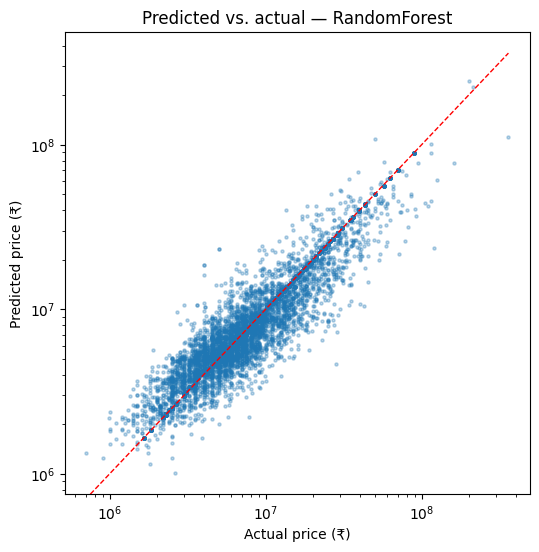

In [24]:
best_name = results_df["RMSE"].idxmin()
best_pred = {"LinearRegression": pred_lin, "RandomForest": pred_rf, "GradientBoosting": pred_gb}[best_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, s=5, alpha=0.3)
lims = [0, max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual price (₹)")
plt.ylabel("Predicted price (₹)")
plt.title(f"Predicted vs. actual — {best_name}")
plt.xscale("log")
plt.yscale("log")
plt.show()

**Model comparison & winner.** `LinearRegression` is a weak baseline (R² ≈ 0.35) —
one-hot categoricals plus a purely linear fit can't capture the non-linear interactions
between location, area, and amenities that drive price. `GradientBoostingRegressor`
(R² ≈ 0.75) does much better by modelling non-linearities, but with only 80 shallow
(depth-3) trees it still underfits somewhat. **`RandomForestRegressor` is the winner**
(R² ≈ 0.88, clearly the lowest MAE and RMSE): its deeper, less-constrained trees capture
the location/area/amenity interactions well, and as an ensemble of many trees it's far
less prone to the extreme extrapolation that hurt the linear baseline. We export the
Random Forest pipeline as the final model.


In [25]:
from sklearn.model_selection import cross_val_score

# Bonus: 5-fold CV on the winning model (RMSE, negated by sklearn's convention)
cv_scores = -cross_val_score(
    fitted[best_name], X_train, y_train, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=1
)
print("5-fold CV RMSE:", cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())

5-fold CV RMSE: [3396309.5605672  5715541.85216319 3721470.98192592 4654730.1996489
 3531246.95895744]
Mean: 4203859.910652529 Std: 874724.0866762549


## 2.6 Export the Model

In [26]:
import joblib

final_model = fitted[best_name]
joblib.dump(final_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual price:       ", y_test.iloc[0])

Reloaded prediction: [12596654.88130846]
Actual price:        18500000.0


In [27]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved", df["location_grouped"].nunique(), "locations to locations.json")

Saved 51 locations to locations.json


In [28]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt so the pickle loads reliably.")

scikit-learn version: 1.8.0
Pin this exact version in backend/requirements.txt so the pickle loads reliably.
